In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from scipy.stats import ttest_ind
from scipy.stats import shapiro
from scipy.stats import mannwhitneyu, norm
from scipy.stats import spearmanr

In [4]:
df = pd.read_csv("Smoking.csv")

DATA UNDERSTANDING

In [5]:
print("Tampilan Isi Dataset")
df.head()

Tampilan Isi Dataset


,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,F,40,155,60,81.3,1.2,1.0,1.0,1.0,...,12.9,1.0,0.7,18.0,19.0,27.0,Y,0,Y,0
1,1,F,40,160,60,81.0,0.8,0.6,1.0,1.0,...,12.7,1.0,0.6,22.0,19.0,18.0,Y,0,Y,0
2,2,M,55,170,60,80.0,0.8,0.8,1.0,1.0,...,15.8,1.0,1.0,21.0,16.0,22.0,Y,0,N,1
3,3,M,40,165,70,88.0,1.5,1.5,1.0,1.0,...,14.7,1.0,1.0,19.0,26.0,18.0,Y,0,Y,0
4,4,F,40,155,60,86.0,1.0,1.0,1.0,1.0,...,12.5,1.0,0.6,16.0,14.0,22.0,Y,0,N,0


In [6]:
print("Statistik Deskriptif Dataset")
df.describe(include='all')

Statistik Deskriptif Dataset


,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
count,55692.000000,55692,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,...,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692,55692.000000,55692,55692.000000
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,2,NaN
top,NaN,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,Y,NaN
freq,NaN,35401,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,55692,NaN,30940,NaN
mean,27845.500000,NaN,44.182917,164.649321,65.864936,82.046418,1.012623,1.007443,1.025587,1.026144,...,14.622592,1.087212,0.885738,26.182935,27.036037,39.952201,NaN,0.213334,NaN,0.367288
std,16077.039933,NaN,12.071418,9.194597,12.820306,9.274223,0.486873,0.485964,0.157902,0.159564,...,1.564498,0.404882,0.221524,19.355460,30.947853,50.290539,NaN,0.409665,NaN,0.482070
min,0.000000,NaN,20.000000,130.000000,30.000000,51.000000,0.100000,0.100000,1.000000,1.000000,...,4.900000,1.000000,0.100000,6.000000,1.000000,1.000000,NaN,0.000000,NaN,0.000000
25%,13922.750000,NaN,40.000000,160.000000,55.000000,76.000000,0.800000,0.800000,1.000000,1.000000,...,13.600000,1.000000,0.800000,19.000000,15.000000,17.000000,NaN,0.000000,NaN,0.000000
50%,27845.500000,NaN,40.000000,165.000000,65.000000,82.000000,1.000000,1.000000,1.000000,1.000000,...,14.800000,1.000000,0.900000,23.000000,21.000000,25.000000,NaN,0.000000,NaN,0.000000
75%,41768.250000,NaN,55.000000,170.000000,75.000000,88.000000,1.200000,1.200000,1.000000,1.000000,...,15.800000,1.000000,1.000000,28.000000,31.000000,43.000000,NaN,0.000000,NaN,1.000000


In [7]:
print("Informasi Kolom Dataset")
df.info()

Informasi Kolom Dataset
<class 'pandas.DataFrame'>
RangeIndex: 55692 entries, 0 to 55691
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   55692 non-null  int64  
 1   gender               55692 non-null  str    
 2   age                  55692 non-null  int64  
 3   height(cm)           55692 non-null  int64  
 4   weight(kg)           55692 non-null  int64  
 5   waist(cm)            55692 non-null  float64
 6   eyesight(left)       55692 non-null  float64
 7   eyesight(right)      55692 non-null  float64
 8   hearing(left)        55692 non-null  float64
 9   hearing(right)       55692 non-null  float64
 10  systolic             55692 non-null  float64
 11  relaxation           55692 non-null  float64
 12  fasting blood sugar  55692 non-null  float64
 13  Cholesterol          55692 non-null  float64
 14  triglyceride         55692 non-null  float64
 15  HDL                  55

DATA WRANGLING

In [8]:
constant_columns = [col for col in df.columns if df[col].nunique() <= 1]
print(f"Kolom dengan nilai konstan (tidak relevan): {constant_columns}")
cols_to_drop = ['ID'] + constant_columns
df_clean = df.drop(columns=cols_to_drop)

Kolom dengan nilai konstan (tidak relevan): ['oral']


In [9]:
df_clean.isnull().sum()

gender                 0
age                    0
height(cm)             0
weight(kg)             0
waist(cm)              0
eyesight(left)         0
eyesight(right)        0
hearing(left)          0
hearing(right)         0
systolic               0
relaxation             0
fasting blood sugar    0
Cholesterol            0
triglyceride           0
HDL                    0
LDL                    0
hemoglobin             0
Urine protein          0
serum creatinine       0
AST                    0
ALT                    0
Gtp                    0
dental caries          0
tartar                 0
smoking                0
dtype: int64

In [10]:
data_duplikat = df_clean.duplicated().sum()
print(f"Jumlah data duplikat sebanyak {data_duplikat} baris")

Jumlah data duplikat sebanyak 11140 baris


In [11]:
df_final = df_clean.drop_duplicates()

print(f"Ukuran dataset sebelum: {df_clean.shape}")
print(f"Ukuran dataset setelah data wrangling: {df_final.shape}")

Ukuran dataset sebelum: (55692, 25)
Ukuran dataset setelah data wrangling: (44552, 25)


In [12]:
print("Statistik Deskriptif Dataset")
df_clean.describe(include='all')

Statistik Deskriptif Dataset


,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,tartar,smoking
count,55692,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,...,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692,55692.000000
unique,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN
top,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN
freq,35401,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30940,NaN
mean,NaN,44.182917,164.649321,65.864936,82.046418,1.012623,1.007443,1.025587,1.026144,121.494218,...,114.964501,14.622592,1.087212,0.885738,26.182935,27.036037,39.952201,0.213334,NaN,0.367288
std,NaN,12.071418,9.194597,12.820306,9.274223,0.486873,0.485964,0.157902,0.159564,13.675989,...,40.926476,1.564498,0.404882,0.221524,19.355460,30.947853,50.290539,0.409665,NaN,0.482070
min,NaN,20.000000,130.000000,30.000000,51.000000,0.100000,0.100000,1.000000,1.000000,71.000000,...,1.000000,4.900000,1.000000,0.100000,6.000000,1.000000,1.000000,0.000000,NaN,0.000000
25%,NaN,40.000000,160.000000,55.000000,76.000000,0.800000,0.800000,1.000000,1.000000,112.000000,...,92.000000,13.600000,1.000000,0.800000,19.000000,15.000000,17.000000,0.000000,NaN,0.000000
50%,NaN,40.000000,165.000000,65.000000,82.000000,1.000000,1.000000,1.000000,1.000000,120.000000,...,113.000000,14.800000,1.000000,0.900000,23.000000,21.000000,25.000000,0.000000,NaN,0.000000
75%,NaN,55.000000,170.000000,75.000000,88.000000,1.200000,1.200000,1.000000,1.000000,130.000000,...,136.000000,15.800000,1.000000,1.000000,28.000000,31.000000,43.000000,0.000000,NaN,1.000000


In [13]:
print("Informasi Kolom Dataset")
df_clean.info()

Informasi Kolom Dataset
<class 'pandas.DataFrame'>
RangeIndex: 55692 entries, 0 to 55691
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               55692 non-null  str    
 1   age                  55692 non-null  int64  
 2   height(cm)           55692 non-null  int64  
 3   weight(kg)           55692 non-null  int64  
 4   waist(cm)            55692 non-null  float64
 5   eyesight(left)       55692 non-null  float64
 6   eyesight(right)      55692 non-null  float64
 7   hearing(left)        55692 non-null  float64
 8   hearing(right)       55692 non-null  float64
 9   systolic             55692 non-null  float64
 10  relaxation           55692 non-null  float64
 11  fasting blood sugar  55692 non-null  float64
 12  Cholesterol          55692 non-null  float64
 13  triglyceride         55692 non-null  float64
 14  HDL                  55692 non-null  float64
 15  LDL                  55

RINGKASAN DATASET

In [14]:
total_sampel = len(df_final)

total_perokok = df_final[df_final['smoking'] == 1].shape[0]
persen_perokok = (total_perokok/total_sampel)*100

total_pria = df_final[df_final['gender'] == 'M'].shape[0]
perokok_pria = df_final[(df_final['gender'] == 'M') & (df_final['smoking'] == 1)].shape[0]
persen_perokok_pria = (perokok_pria / total_pria) * 100

total_wanita = df_final[df_final['gender'] == 'F'].shape[0]
perokok_wanita = df_final[(df_final['gender'] == 'F') & (df_final['smoking'] == 1)].shape[0]
persen_perokok_wanita = (perokok_wanita / total_wanita) * 100

total_variabel = df_final.shape[1]

print("-" * 40)
print(" "*10, "RINGKASAN DATASET", " "*11)
print("-" * 40)
print(f"Total Sampel (Unique)      : {total_sampel:} orang")
print(f"Total Perokok              : {total_perokok:} orang ({persen_perokok:.2f}%)")
print(f"Total Variabel Analisis    : {total_variabel} kolom")
print("-" * 40)
print(f"Prevalensi Perokok Pria      : {perokok_pria:} dari {total_pria:} pria ({persen_perokok_pria:.2f}%)")
print(f"Prevalensi Perokok Wanita    : {perokok_wanita:} dari {total_wanita:} wanita ({persen_perokok_wanita:.2f}%)")
print("-" * 40)

----------------------------------------
           RINGKASAN DATASET            
----------------------------------------
Total Sampel (Unique)      : 44552 orang
Total Perokok              : 16352 orang (36.70%)
Total Variabel Analisis    : 25 kolom
----------------------------------------
Prevalensi Perokok Pria      : 15650 dari 28349 pria (55.20%)
Prevalensi Perokok Wanita    : 702 dari 16203 wanita (4.33%)
----------------------------------------


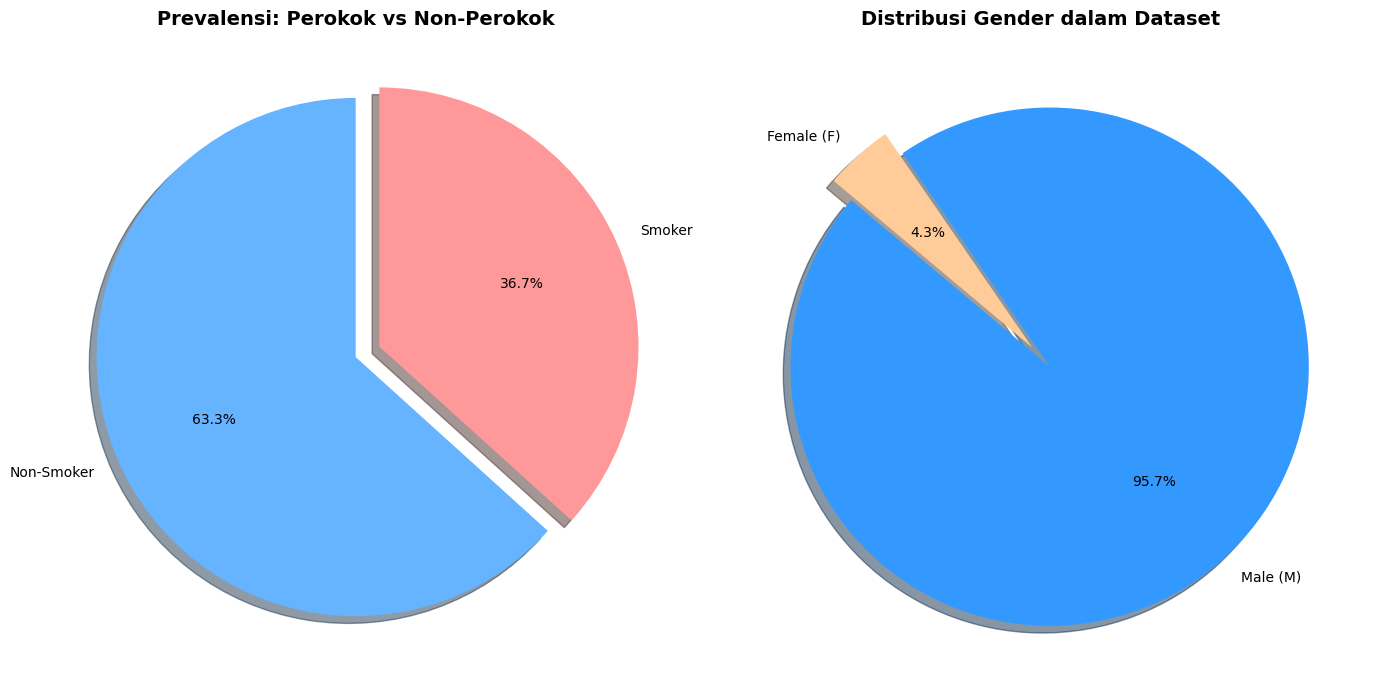

In [15]:
smoking_counts = df_final['smoking'].value_counts()
labels_smoking = ['Non-Smoker', 'Smoker']

smokers_df = df_final[df_final['smoking'] == 1]
gender_counts = smokers_df['gender'].value_counts()
labels_gender = ['Male (M)', 'Female (F)'] # Sesuaikan urutan dengan hasil value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

colors1 = ['#66b3ff','#ff9999']
ax1.pie(smoking_counts, labels=labels_smoking, autopct='%1.1f%%', 
        startangle=90, colors=colors1, explode=(0, 0.1), shadow=True)
ax1.set_title('Prevalensi: Perokok vs Non-Perokok', fontsize=14, fontweight='bold')

colors2 = ['#3399ff','#ffcc99']
ax2.pie(gender_counts, 
        labels=labels_gender, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors2, 
        explode=(0.05, 0.05), 
        shadow=True)
ax2.set_title('Distribusi Gender dalam Dataset', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\ivana\AppData\Local\Temp\ipykernel_6272\2114576617.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Gender', y='Percentage', data=prevalence, palette='viridis')


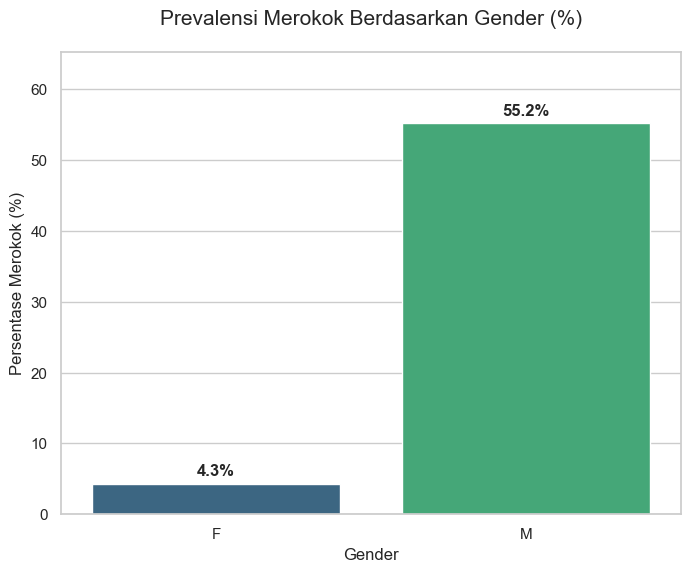

In [16]:
prevalence = df_final.groupby('gender')['smoking'].mean() * 100
prevalence = prevalence.reset_index()
prevalence.columns = ['Gender', 'Percentage']

plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(x='Gender', y='Percentage', data=prevalence, palette='viridis')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

plt.title('Prevalensi Merokok Berdasarkan Gender (%)', fontsize=15, pad=20)
plt.ylabel('Persentase Merokok (%)', fontsize=12)
plt.xlabel('Gender', fontsize=12)
plt.ylim(0, max(prevalence['Percentage']) + 10) # Memberi ruang di atas bar

plt.show()

In [17]:
stats_desc = df_final.describe().T
stats_desc['range'] = stats_desc['max'] - stats_desc['min']
stats_desc['CV(%)'] = (stats_desc['std'] / stats_desc['mean']) * 100

print(stats_desc[['mean', '50%', 'std', 'range', 'CV(%)']])

                           mean    50%        std   range       CV(%)
age                   44.210698   40.0  12.089196    65.0   27.344505
height(cm)           164.657030  165.0   9.198674    60.0    5.586566
weight(kg)            65.883462   65.0  12.823819   105.0   19.464398
waist(cm)             82.077186   82.0   9.278384    78.0   11.304461
eyesight(left)         1.011730    1.0   0.488136     9.8   48.247655
eyesight(right)        1.008130    1.0   0.488767     9.8   48.482512
hearing(left)          1.025611    1.0   0.157972     1.0   15.402738
hearing(right)         1.026037    1.0   0.159247     1.0   15.520599
systolic             121.529179  120.0  13.688876   169.0   11.263860
relaxation            76.043320   76.0   9.695356   106.0   12.749779
fasting blood sugar   99.320210   96.0  20.845547   459.0   20.988223
Cholesterol          196.996005  195.0  36.423237   390.0   18.489328
triglyceride         126.722257  108.0  71.612721   991.0   56.511557
HDL                 

In [18]:
df_final['gender_numeric'] = df_final['gender'].map({'M': 1, 'F': 0})
correlations = df_final.corr(numeric_only=True)['smoking'].sort_values(ascending=False)

print("--- Kekuatan Korelasi terhadap Status Merokok (Seluruh Data) ---")
print(correlations)

--- Kekuatan Korelasi terhadap Status Merokok (Seluruh Data) ---
smoking                1.000000
gender_numeric         0.507735
hemoglobin             0.397289
height(cm)             0.393706
weight(kg)             0.299443
triglyceride           0.250896
Gtp                    0.234934
waist(cm)              0.224525
serum creatinine       0.209255
relaxation             0.107571
dental caries          0.105277
fasting blood sugar    0.099401
ALT                    0.094384
systolic               0.073618
eyesight(right)        0.062432
AST                    0.059884
eyesight(left)         0.059386
Urine protein          0.015757
hearing(right)        -0.018060
hearing(left)         -0.023519
Cholesterol           -0.030187
LDL                   -0.045016
age                   -0.161127
HDL                   -0.175895
Name: smoking, dtype: float64


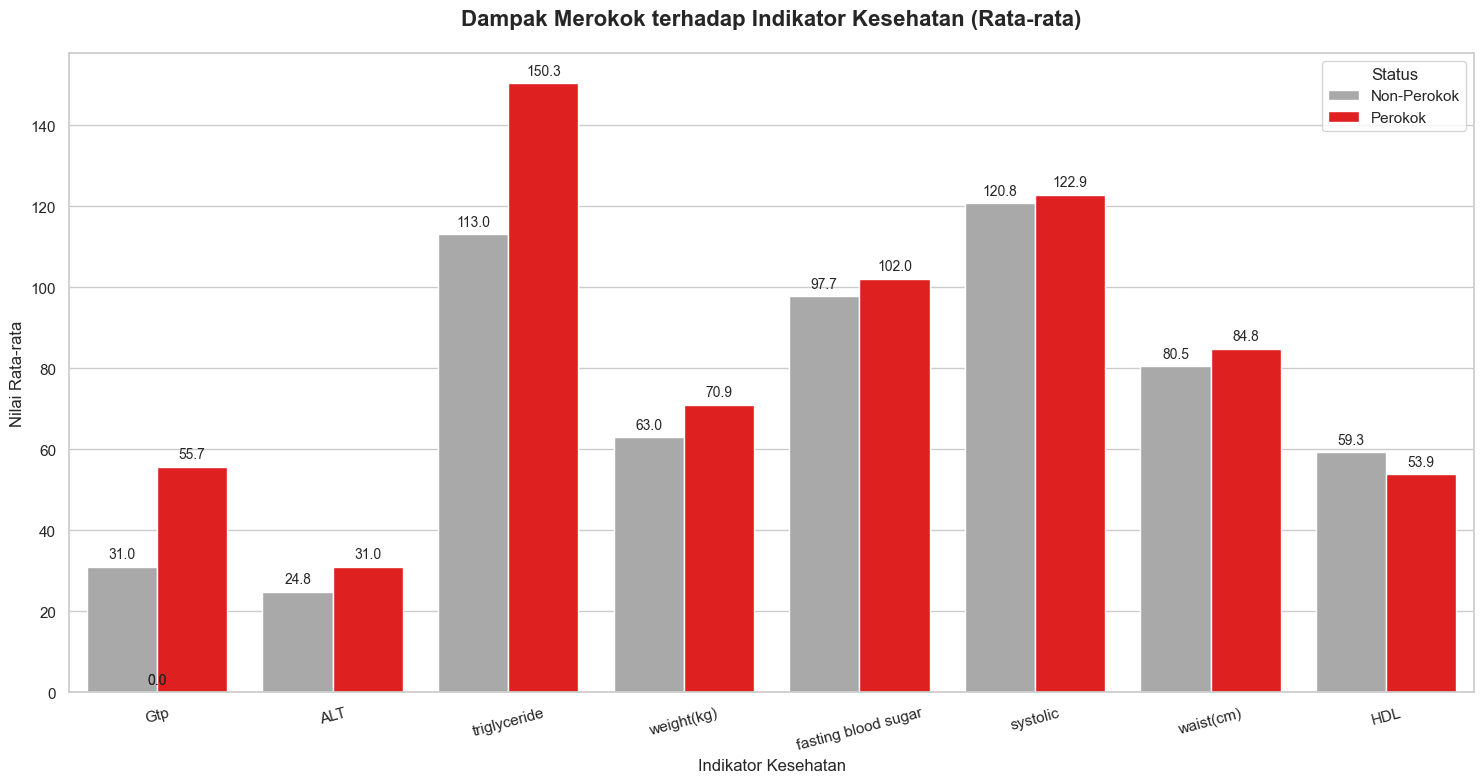

In [19]:
target_cols = [
    'Gtp', 'ALT', 'triglyceride', 'weight(kg)', 
    'fasting blood sugar', 'systolic', 'waist(cm)', 'HDL'
]

df_grouped = df_final.groupby('smoking')[target_cols].mean().reset_index()
df_melted = df_grouped.melt(id_vars='smoking', var_name='Biomarker', value_name='Average Value')
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")
plot = sns.barplot(
    data=df_melted,
    x='Biomarker',
    y='Average Value',
    hue='smoking',
    palette={0: '#A9A9A9', 1: '#FF0000'} # Abu-abu untuk Non-Perokok, Merah untuk Perokok
)
plt.title('Dampak Merokok terhadap Indikator Kesehatan (Rata-rata)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Indikator Kesehatan', fontsize=12)
plt.ylabel('Nilai Rata-rata', fontsize=12)
plt.xticks(rotation=15)
handles, labels = plot.get_legend_handles_labels()
plt.legend(handles=handles, labels=['Non-Perokok', 'Perokok'], title='Status')

for p in plot.patches:
    plot.annotate(format(p.get_height(), '.1f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=10)

plt.tight_layout()
plt.show()

Tabel Tren Prevalensi Merokok berdasarkan Usia:
  Kelompok Usia  Prevalensi Merokok (%)
0         20-30               47.795371
1         30-40               50.241758
2         40-50               35.949924
3         50-60               31.891573
4         60-70               27.203065
5         70-80               19.031142
6         80-90               11.020408


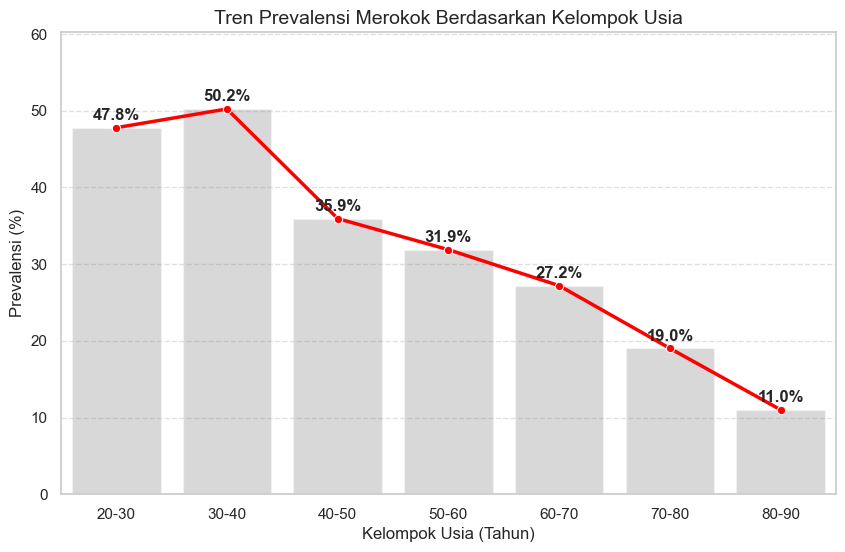

In [20]:
bins = [20, 30, 40, 50, 60, 70, 80, 90]
labels = ['20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90']
df_final['age_group'] = pd.cut(df_final['age'], bins=bins, labels=labels, right=False)

age_trend = df_final.groupby('age_group')['smoking'].mean() * 100
age_trend = age_trend.reset_index()
age_trend.columns = ['Kelompok Usia', 'Prevalensi Merokok (%)']

print("Tabel Tren Prevalensi Merokok berdasarkan Usia:")
print(age_trend)

plt.figure(figsize=(10, 6))
sns.lineplot(data=age_trend, x='Kelompok Usia', y='Prevalensi Merokok (%)', marker='o', color='red', linewidth=2.5)
sns.barplot(data=age_trend, x='Kelompok Usia', y='Prevalensi Merokok (%)', alpha=0.3, color='grey')
plt.title('Tren Prevalensi Merokok Berdasarkan Kelompok Usia', fontsize=14)
plt.xlabel('Kelompok Usia (Tahun)', fontsize=12)
plt.ylabel('Prevalensi (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylim(0, age_trend['Prevalensi Merokok (%)'].max() + 10)

for i, val in enumerate(age_trend['Prevalensi Merokok (%)']):
    plt.text(i, val + 1, f'{val:.1f}%', ha='center', fontweight='bold')

plt.show()

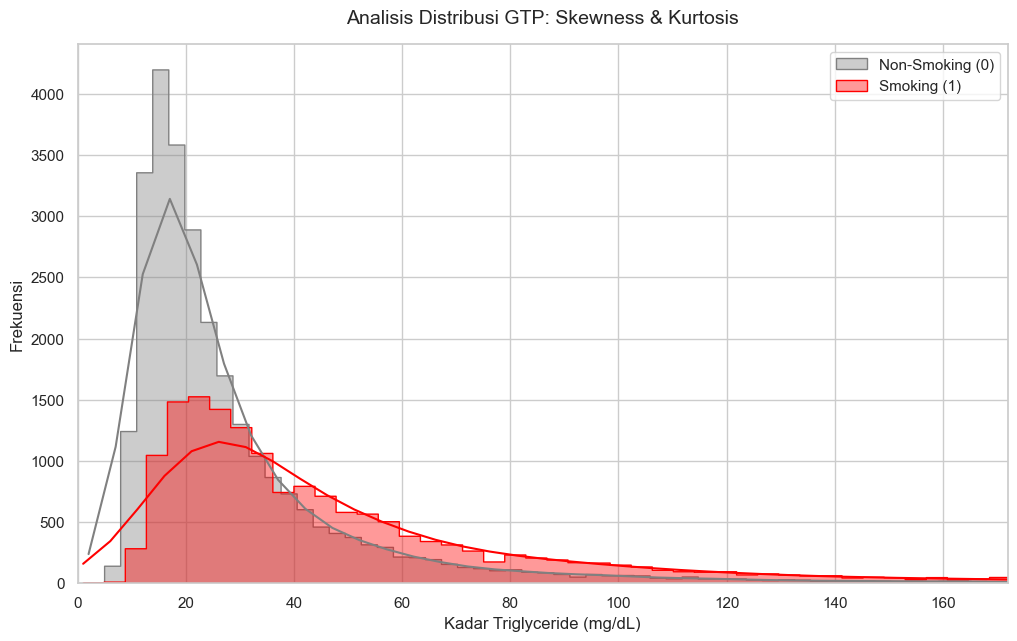

Triglyceride [Non-Smoking] -> Skewness: 8.28, Kurtosis: 123.28
Triglyceride [Smoking]     -> Skewness: 5.56, Kurtosis: 48.10


In [21]:
skew_non = df_final[df_final['smoking'] == 0]['Gtp'].skew()
skew_smoke = df_final[df_final['smoking'] == 1]['Gtp'].skew()

kurt_non = df_final[df_final['smoking'] == 0]['Gtp'].kurt()
kurt_smoke = df_final[df_final['smoking'] == 1]['Gtp'].kurt()

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")
sns.histplot(data=df_final[df_final['smoking'] == 0], x='Gtp', kde=True, 
             label='Non-Smoking (0)', color='grey', alpha=0.4, element='step')
sns.histplot(data=df_final[df_final['smoking'] == 1], x='Gtp', kde=True, 
             label='Smoking (1)', color='red', alpha=0.4, element='step')
plt.title('Analisis Distribusi GTP: Skewness & Kurtosis', fontsize=14, pad=15)
plt.xlabel('Kadar Triglyceride (mg/dL)', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.xlim(0, df_final['Gtp'].quantile(0.98)) 
plt.legend()
plt.show()

print(f"Triglyceride [Non-Smoking] -> Skewness: {skew_non:.2f}, Kurtosis: {kurt_non:.2f}")
print(f"Triglyceride [Smoking]     -> Skewness: {skew_smoke:.2f}, Kurtosis: {kurt_smoke:.2f}")

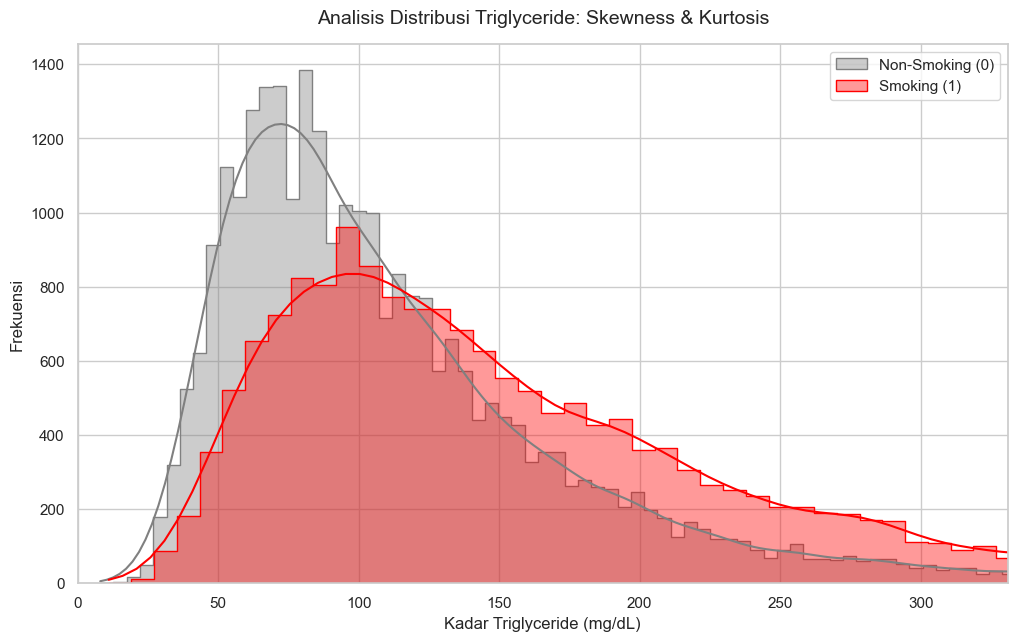

Triglyceride [Non-Smoking] -> Skewness: 1.51, Kurtosis: 2.67
Triglyceride [Smoking]     -> Skewness: 1.02, Kurtosis: 1.21


In [22]:
skew_non = df_final[df_final['smoking'] == 0]['triglyceride'].skew()
skew_smoke = df_final[df_final['smoking'] == 1]['triglyceride'].skew()
kurt_non = df_final[df_final['smoking'] == 0]['triglyceride'].kurt()
kurt_smoke = df_final[df_final['smoking'] == 1]['triglyceride'].kurt()

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")
sns.histplot(data=df_final[df_final['smoking'] == 0], x='triglyceride', kde=True, 
             label='Non-Smoking (0)', color='grey', alpha=0.4, element='step')
sns.histplot(data=df_final[df_final['smoking'] == 1], x='triglyceride', kde=True, 
             label='Smoking (1)', color='red', alpha=0.4, element='step')
plt.title('Analisis Distribusi Triglyceride: Skewness & Kurtosis', fontsize=14, pad=15)
plt.xlabel('Kadar Triglyceride (mg/dL)', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.xlim(0, df_final['triglyceride'].quantile(0.98)) 
plt.legend()
plt.show()

print(f"Triglyceride [Non-Smoking] -> Skewness: {skew_non:.2f}, Kurtosis: {kurt_non:.2f}")
print(f"Triglyceride [Smoking]     -> Skewness: {skew_smoke:.2f}, Kurtosis: {kurt_smoke:.2f}")

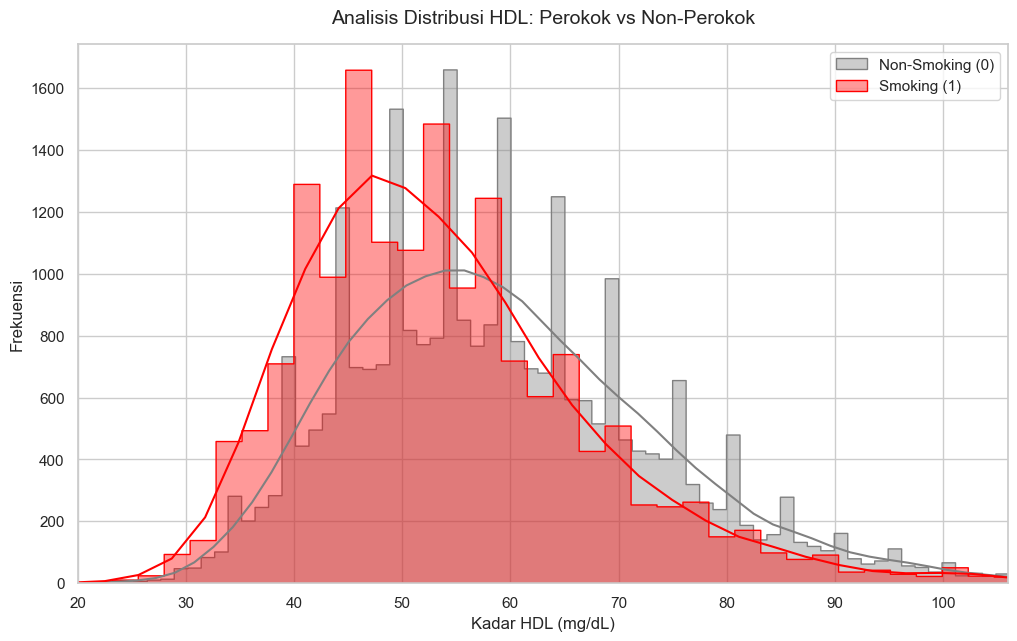

HDL [Non-Smoking] -> Skewness: 1.05, Kurtosis: 7.09
HDL [Smoking]     -> Skewness: 4.65, Kurtosis: 148.23


In [23]:
skew_non = df_final[df_final['smoking'] == 0]['HDL'].skew()
skew_smoke = df_final[df_final['smoking'] == 1]['HDL'].skew()
kurt_non = df_final[df_final['smoking'] == 0]['HDL'].kurt()
kurt_smoke = df_final[df_final['smoking'] == 1]['HDL'].kurt()

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")
sns.histplot(data=df_final[df_final['smoking'] == 0], x='HDL', kde=True, 
             label='Non-Smoking (0)', color='grey', alpha=0.4, element='step')
sns.histplot(data=df_final[df_final['smoking'] == 1], x='HDL', kde=True, 
             label='Smoking (1)', color='red', alpha=0.4, element='step')
plt.title('Analisis Distribusi HDL: Perokok vs Non-Perokok', fontsize=14, pad=15)
plt.xlabel('Kadar HDL (mg/dL)', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.xlim(20, df_final['HDL'].quantile(0.995)) 
plt.legend()
plt.show()

print(f"HDL [Non-Smoking] -> Skewness: {skew_non:.2f}, Kurtosis: {kurt_non:.2f}")
print(f"HDL [Smoking]     -> Skewness: {skew_smoke:.2f}, Kurtosis: {kurt_smoke:.2f}")

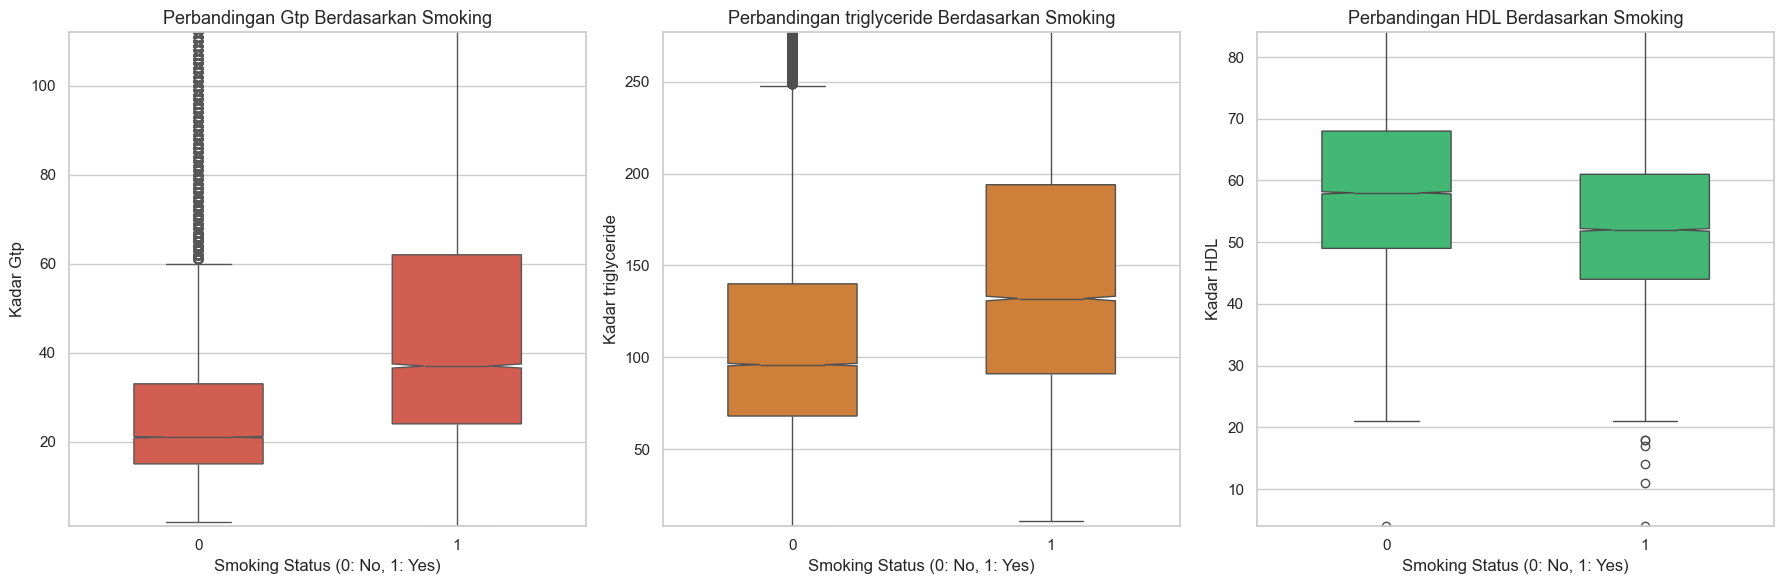

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.set_theme(style="whitegrid")
variables = ['Gtp', 'triglyceride', 'HDL']
colors = ['#e74c3c', '#e67e22', '#2ecc71']

for i, var in enumerate(variables):
    sns.boxplot(data=df_final, x="smoking", y=var, ax=axes[i],
                notch=True, color=colors[i], width=0.5)
    axes[i].set_title(f'Perbandingan {var} Berdasarkan Smoking', fontsize=13)
    axes[i].set_xlabel('Smoking Status (0: No, 1: Yes)')
    axes[i].set_ylabel(f'Kadar {var}')
    upper_limit = df_final[var].quantile(0.95)
    lower_limit = df_final[var].min()
    axes[i].set_ylim(lower_limit, upper_limit)

plt.tight_layout()
plt.show()

In [25]:
def interpret_p(p_value):
    return "Signifikan (Ada perbedaan/hubungan)" if p_value < 0.05 else "Tidak Signifikan (Tidak ada perbedaan/hubungan)"

print("--- ANALISIS UJI STATISTIK ---\n")
group0 = df_final[df_final['smoking'] == 0]['hemoglobin']
group1 = df_final[df_final['smoking'] == 1]['hemoglobin']
t_stat, p_val = stats.ttest_ind(group0, group1)
print(f"1. Hemoglobin vs Smoking:")
print(f"   - P-Value: {p_val:.10f}")
print(f"   - Hasil: {interpret_p(p_val)}")
print(f"   - Rata-rata Hb Non-Smoker: {group0.mean():.2f}")
print(f"   - Rata-rata Hb Smoker: {group1.mean():.2f}\n")

contingency_table = pd.crosstab(df_final['gender'], df_final['smoking'])
chi2, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"2. Gender vs Smoking:")
print(f"   - P-Value: {p_val_chi2:.10f}")
print(f"   - Hasil: {interpret_p(p_val_chi2)}\n")

gtp0 = df_final[df_final['smoking'] == 0]['Gtp']
gtp1 = df_final[df_final['smoking'] == 1]['Gtp']
t_stat_gtp, p_val_gtp = stats.ttest_ind(gtp0, gtp1)
print(f"3. GTP vs Smoking:")
print(f"   - P-Value: {p_val_gtp:.10f}")
print(f"   - Hasil: {interpret_p(p_val_gtp)}")
print(f"   - Rata-rata GTP Non-Smoker: {gtp0.mean():.2f}")
print(f"   - Rata-rata GTP Smoker: {gtp1.mean():.2f}\n")

age0 = df_final[df_final['smoking'] == 0]['age']
age1 = df_final[df_final['smoking'] == 1]['age']
t_stat_age, p_val_age = stats.ttest_ind(age0, age1)
print(f"4. Age vs Smoking:")
print(f"   - P-Value: {p_val_age:.10f}")
print(f"   - Hasil: {interpret_p(p_val_age)}")
print(f"   - Rata-rata Usia Non-Smoker: {age0.mean():.2f}")
print(f"   - Rata-rata Usia Smoker: {age1.mean():.2f}")

tg0 = df_final[df_final['smoking'] == 0]['triglyceride']
tg1 = df_final[df_final['smoking'] == 1]['triglyceride']
t_stat_tg, p_val_tg = stats.ttest_ind(tg0, tg1)
print(f"5. Triglyceride vs Smoking:")
print(f"   - P-Value: {p_val_tg:.10f}")
print(f"   - Hasil: {interpret_p(p_val_tg)}")
print(f"   - Rata-rata Triglyceride Non-Smoker: {tg0.mean():.2f}")
print(f"   - Rata-rata Triglyceride Smoker: {tg1.mean():.2f}\n")

hdl0 = df_final[df_final['smoking'] == 0]['HDL']
hdl1 = df_final[df_final['smoking'] == 1]['HDL']
t_stat_hdl, p_val_hdl = stats.ttest_ind(hdl0, hdl1)
print(f"6. HDL vs Smoking:")
print(f"   - P-Value: {p_val_hdl:.10f}")
print(f"   - Hasil: {interpret_p(p_val_hdl)}")
print(f"   - Rata-rata HDL Non-Smoker: {hdl0.mean():.2f}")
print(f"   - Rata-rata HDL Smoker: {hdl1.mean():.2f}")

--- ANALISIS UJI STATISTIK ---

1. Hemoglobin vs Smoking:
   - P-Value: 0.0000000000
   - Hasil: Signifikan (Ada perbedaan/hubungan)
   - Rata-rata Hb Non-Smoker: 14.15
   - Rata-rata Hb Smoker: 15.44

2. Gender vs Smoking:
   - P-Value: 0.0000000000
   - Hasil: Signifikan (Ada perbedaan/hubungan)

3. GTP vs Smoking:
   - P-Value: 0.0000000000
   - Hasil: Signifikan (Ada perbedaan/hubungan)
   - Rata-rata GTP Non-Smoker: 30.99
   - Rata-rata GTP Smoker: 55.72

4. Age vs Smoking:
   - P-Value: 0.0000000000
   - Hasil: Signifikan (Ada perbedaan/hubungan)
   - Rata-rata Usia Non-Smoker: 45.69
   - Rata-rata Usia Smoker: 41.65
5. Triglyceride vs Smoking:
   - P-Value: 0.0000000000
   - Hasil: Signifikan (Ada perbedaan/hubungan)
   - Rata-rata Triglyceride Non-Smoker: 113.04
   - Rata-rata Triglyceride Smoker: 150.32

6. HDL vs Smoking:
   - P-Value: 0.0000000000
   - Hasil: Signifikan (Ada perbedaan/hubungan)
   - Rata-rata HDL Non-Smoker: 59.27
   - Rata-rata HDL Smoker: 53.87


In [26]:
variables = ['hemoglobin', 'age', 'Gtp', 'triglyceride', 'HDL']
sample_size = 1000

print(f"--- UJI NORMALITAS: SHAPIRO-WILK (Stratified Sampling N={sample_size}) ---")
print("Proporsi kelas 'smoking' tetap dijaga agar sesuai aslinya.\n")

for var in variables:
    df_sample = df_final.groupby('smoking', group_keys=False).apply(
        lambda x: x.sample(frac=sample_size/len(df_final), random_state=42)
    )
    data_to_test = df_sample[var].dropna()
    stat, p_value = shapiro(data_to_test)
    print(f"Variabel: {var}")
    print(f"- W-Statistic: {stat:.4f}")
    print(f"- P-Value: {p_value:.10f}")
    if p_value > 0.05:
        print("- Kesimpulan: Data Terdistribusi Normal (Gagal menolak H0)")
    else:
        print("- Kesimpulan: Data TIDAK Terdistribusi Normal (Menolak H0)")
    print("-" * 55)

--- UJI NORMALITAS: SHAPIRO-WILK (Stratified Sampling N=1000) ---
Proporsi kelas 'smoking' tetap dijaga agar sesuai aslinya.

Variabel: hemoglobin
- W-Statistic: 0.9863
- P-Value: 0.0000000447
- Kesimpulan: Data TIDAK Terdistribusi Normal (Menolak H0)
-------------------------------------------------------
Variabel: age
- W-Statistic: 0.9682
- P-Value: 0.0000000000
- Kesimpulan: Data TIDAK Terdistribusi Normal (Menolak H0)
-------------------------------------------------------
Variabel: Gtp
- W-Statistic: 0.4263
- P-Value: 0.0000000000
- Kesimpulan: Data TIDAK Terdistribusi Normal (Menolak H0)
-------------------------------------------------------
Variabel: triglyceride
- W-Statistic: 0.8905
- P-Value: 0.0000000000
- Kesimpulan: Data TIDAK Terdistribusi Normal (Menolak H0)
-------------------------------------------------------
Variabel: HDL
- W-Statistic: 0.9635
- P-Value: 0.0000000000
- Kesimpulan: Data TIDAK Terdistribusi Normal (Menolak H0)
---------------------------------------

In [27]:
variables = ['Gtp', 'triglyceride', 'HDL']
print("--- ANALISIS NON-PARAMETRIK: MANN-WHITNEY U TEST ---")
print("Alasan: Data tidak normal (berdasarkan uji Shapiro-Wilk)\n")

for var in variables:
    group_non = df_final[df_final['smoking'] == 0][var].dropna()
    group_smoke = df_final[df_final['smoking'] == 1][var].dropna()
    stat, p_value = mannwhitneyu(group_non, group_smoke, alternative='two-sided')
    median_non = group_non.median()
    median_smoke = group_smoke.median()
    
    print(f"Variabel: {var}")
    print(f"- Median Non-Perokok: {median_non:.2f}")
    print(f"- Median Perokok    : {median_smoke:.2f}")
    print(f"- U-Statistic       : {stat:.3f}")
    print(f"- P-Value           : {p_value:.10f}")
    
    if p_value < 0.05:
        status = "SIGNIFIKAN"
        kesimpulan = f"Terdapat perbedaan median {var} yang nyata antara perokok dan non-perokok."
    else:
        status = "TIDAK SIGNIFIKAN"
        kesimpulan = f"Tidak ada perbedaan median {var} yang nyata."
        
    print(f"- Hasil             : {status}")
    print(f"- Kesimpulan        : {kesimpulan}")
    print("-" * 60)

--- ANALISIS NON-PARAMETRIK: MANN-WHITNEY U TEST ---
Alasan: Data tidak normal (berdasarkan uji Shapiro-Wilk)

Variabel: Gtp
- Median Non-Perokok: 21.00
- Median Perokok    : 37.00
- U-Statistic       : 127910020.000
- P-Value           : 0.0000000000
- Hasil             : SIGNIFIKAN
- Kesimpulan        : Terdapat perbedaan median Gtp yang nyata antara perokok dan non-perokok.
------------------------------------------------------------
Variabel: triglyceride
- Median Non-Perokok: 96.00
- Median Perokok    : 132.00
- U-Statistic       : 159874202.500
- P-Value           : 0.0000000000
- Hasil             : SIGNIFIKAN
- Kesimpulan        : Terdapat perbedaan median triglyceride yang nyata antara perokok dan non-perokok.
------------------------------------------------------------
Variabel: HDL
- Median Non-Perokok: 58.00
- Median Perokok    : 52.00
- U-Statistic       : 283959370.500
- P-Value           : 0.0000000000
- Hasil             : SIGNIFIKAN
- Kesimpulan        : Terdapat perbe

In [28]:
variables = ['Gtp', 'triglyceride', 'HDL', 'age', 'hemoglobin']
results = []

for var in variables:
    # Memisahkan data
    group0 = df_final[df_final['smoking'] == 0][var].dropna()
    group1 = df_final[df_final['smoking'] == 1][var].dropna()
    n1 = len(group0)
    n2 = len(group1)
    stat, p_value = mannwhitneyu(group0, group1, alternative='two-sided')
    r = abs(1 - (2 * stat) / (n1 * n2))
    if r < 0.1:
        magnitude = "Negligible (Sangat Kecil)"
    elif r < 0.3:
        magnitude = "Small (Kecil)"
    elif r < 0.5:
        magnitude = "Medium (Sedang)"
    else:
        magnitude = "Large (Besar)"
        
    results.append({
        'Variable': var,
        'P-Value': p_value,
        'Effect Size (r)': round(r, 4),
        'Magnitude': magnitude
    })

df_effect = pd.DataFrame(results).sort_values(by='Effect Size (r)', ascending=False)
print("--- ANALISIS EFFECT SIZE (RANK-BISERIAL CORRELATION) ---")
print(df_effect.to_string(index=False))

--- ANALISIS EFFECT SIZE (RANK-BISERIAL CORRELATION) ---
    Variable       P-Value  Effect Size (r)       Magnitude
  hemoglobin  0.000000e+00           0.4953 Medium (Sedang)
         Gtp  0.000000e+00           0.4452 Medium (Sedang)
triglyceride  0.000000e+00           0.3066 Medium (Sedang)
         HDL  0.000000e+00           0.2316   Small (Kecil)
         age 4.938856e-258           0.1922   Small (Kecil)


--- ANALISIS KORELASI: HEMOGLOBIN VS GTP ---
Koefisien Korelasi Spearman: 0.4493
P-Value: 0.0000000000


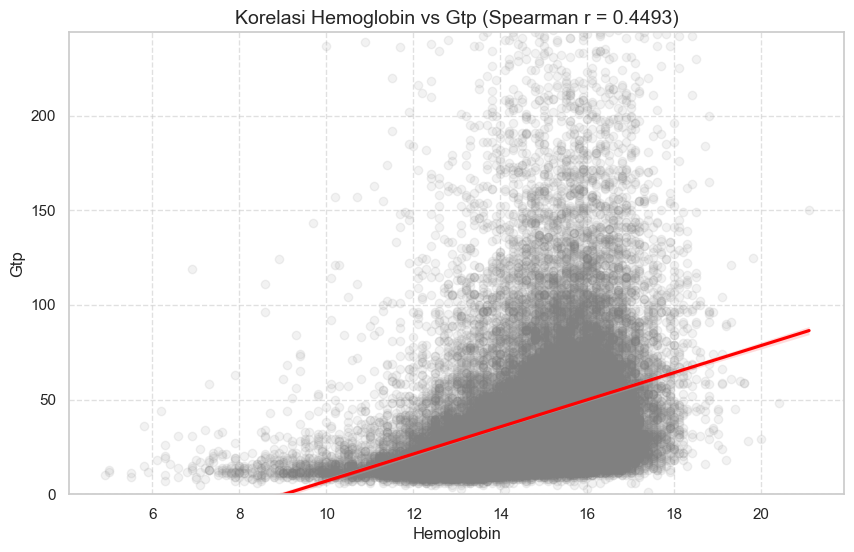

In [29]:
corr, p_val = spearmanr(df['hemoglobin'], df['Gtp'], nan_policy='omit')

print(f"--- ANALISIS KORELASI: HEMOGLOBIN VS GTP ---")
print(f"Koefisien Korelasi Spearman: {corr:.4f}")
print(f"P-Value: {p_val:.10f}")

plt.figure(figsize=(10, 6))
sns.regplot(data=df_final, x='hemoglobin', y='Gtp', 
            scatter_kws={'alpha':0.1, 'color':'gray'}, 
            line_kws={'color':'red'})
plt.title(f'Korelasi Hemoglobin vs Gtp (Spearman r = {corr:.4f})', fontsize=14)
plt.xlabel('Hemoglobin')
plt.ylim(0, df_final['Gtp'].quantile(0.99)) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()